## We are going 3D


In [ ]:
from image_processing import *
import cv2
import numpy as np

# Load and convert images to grayscale if not already
img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
1.26.4


In [2]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")

In [58]:
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

print(P_left)
print(P_right)

Q = calculate_q_matrix(P_left, P_right)
print(Q)

[[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]
[[ 7.070493e+02  0.000000e+00  6.040814e+02 -3.341081e+02]
 [ 0.000000e+00  7.070493e+02  1.805066e+02  2.330660e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  3.201153e-03]]
[[   1.            0.            0.         -604.0814    ]
 [   0.            1.            0.         -180.5066    ]
 [   0.            0.            0.         -707.0493    ]
 [   0.            0.           -2.11622915    0.        ]]


In [59]:
from matplotlib import pyplot as plt
def plot_disparity_map(disp_map):
    """
    Plot the disparity map using Matplotlib.

    Parameters:
    - disp_map: Disparity map generated from compute_disparity_map function.
    """
    # Set the minimum and maximum disparity values for visualization
    plt.figure(figsize=(10, 7))
    plt.imshow(disp_map, cmap='plasma')
    plt.colorbar(label='Disparity Value')
    plt.title("Disparity Map")
    plt.xlabel("X-axis (pixels)")
    plt.ylabel("Y-axis (pixels)")
    plt.show()

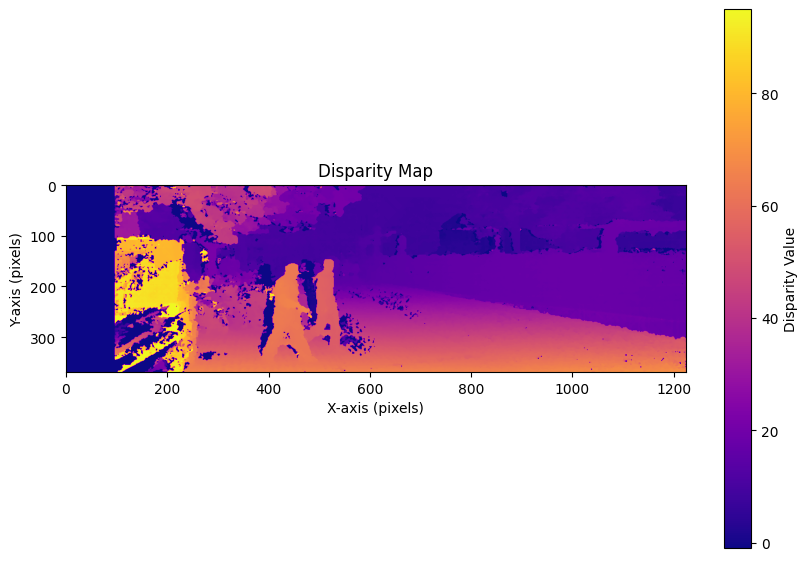

Diparity map range: -1.0 95.0


In [60]:
disp_map = compute_disparity_map(img1, img2,min_disparity=0, num_disparities=6*16, block_size=2)

plot_disparity_map(disp_map)

print(f'Diparity map range: {disp_map.min()} {disp_map.max()}')

In [ ]:


points, colors = generate_point_cloud(disp_map, Q, color_image=color_img, max_z=20)
print(points)
print(points[:,2].max())
print(points[:,2].min())

[[10.611628   3.770004  14.767209 ]
 [10.590742   3.770004  14.767209 ]
 [14.220772   5.092319  19.946753 ]
 ...
 [-4.1547494 -1.2735715  4.7772384]
 [-4.1393113 -1.2667792  4.7517595]
 [-4.164541  -1.2724344  4.772973 ]]
19.946753
3.5169275


In [64]:


# Visualize
visualize_point_cloud(points, colors)



## 3D-point occlusion

In [7]:
from image_processing import *
import cv2

# Load and convert images to grayscale if not already
rect_img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
rect_img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)

In [8]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

In [9]:
bb_path = r"../bb_000000.txt"
bounding_boxes_dict = extract_bbox_from_txt(bb_path)
bounding_boxes = bounding_boxes_dict["bbox"]
bbox_mask = create_bbox_mask(rect_img1.shape, bounding_boxes)

In [11]:
point_cloud = RectImg2PC(rect_img1, rect_img2, P_left, P_right, color_img=color_img, mask=bbox_mask)

In [ ]:
o3d.visualization.draw_geometries([point_cloud])
o3d.io.write_point_cloud('filtered_point_cloud.ply', point_cloud)

# Same but segmentation instead of Bbox

In [1]:
from image_processing import *
import cv2

# Load and convert images to grayscale if not already
rect_img1 = cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png', cv2.IMREAD_GRAYSCALE)
rect_img2 = cv2.imread('../34759_final_project_rect/seq_01/image_03/data/000000.png', cv2.IMREAD_GRAYSCALE)
# Load the color image and apply the mask to get colors for valid points
color_img = cv2.cvtColor(cv2.imread('../34759_final_project_rect/seq_01/image_02/data/000000.png'), cv2.COLOR_BGR2RGB)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Load calibration file and parse it
calibration = parse_calibration_data("../34759_final_project_rect/calib_cam_to_cam.txt")
P_left = calibration["P_rect_02"]
P_right = calibration["P_rect_03"]

In [4]:
seg_path = r"../points.json"
seg_mask = create_seg_mask(file_path=seg_path, image_shape=rect_img1.shape, target_class_labels=None)


In [5]:
point_cloud = RectImg2PC(rect_img1, rect_img2, P_left, P_right, max_z=20, color_img=color_img, mask=seg_mask)

In [6]:
o3d.visualization.draw_geometries([point_cloud])
o3d.io.write_point_cloud('filtered_point_cloud.ply', point_cloud)

True